In [1]:
import os
import numpy as np

In [3]:
import torch
from sbi import utils as Ut
from sbi import inference as Inference

In [4]:
# --- plotting --- 
import corner as DFM
import matplotlib as mpl
import matplotlib.pyplot as plt
#mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

# 1. Load in latent variables, $A_{\rm ivar}$, $A_{\rm spec}$, $z$
* latent variables $\{ h_1, h_2, h_3, h_4, h_5 \}$
* $A_{\rm ivar}$ is the median amplitude of the measured IVAR
* $A_{\rm spec}$ is the median amplitude of the measured spectra 
* $z$ is redshift

Our noise model will be an estimate of $$p({\bf h}, A_{\rm ivar}\,|\,A_{\rm spec}, z) \approx q_\phi({\bf h}, A_{\rm ivar}\,|\,A_{\rm spec}, z)$$ 


In [5]:
dat_dir = '/scratch/network/chhahn/sedflow/spectra/'
i_best = 6
h_ivar = np.load(os.path.join(dat_dir, f'ivar.vae_model.{i_best}.latvar.npy'))
A_ivar = np.load(os.path.join(dat_dir, f'ivar.vae_model.{i_best}.ivar_norm.npy'))
A_spec = np.load(os.path.join(dat_dir, f'ivar.vae_model.{i_best}.spec_norm.npy'))
zred = np.load(os.path.join(dat_dir, f'ivar.vae_model.{i_best}.zred.npy'))

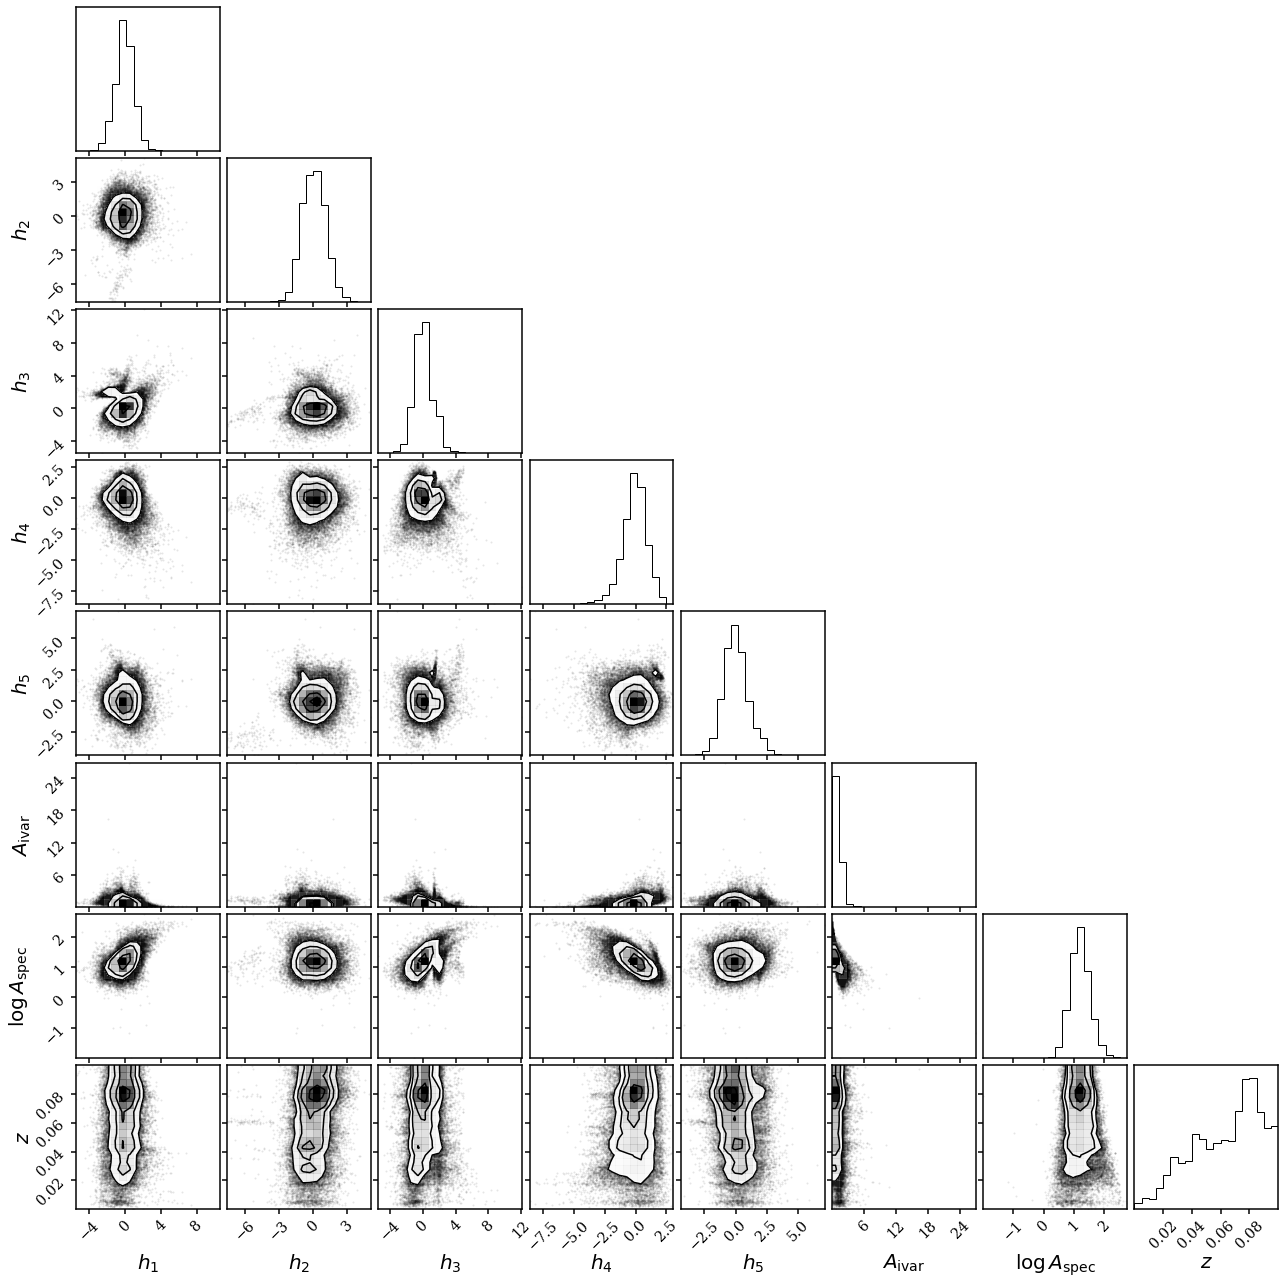

In [6]:
fig = DFM.corner(np.concatenate([h_ivar, A_ivar, np.log10(A_spec.clip(1e-2, None)), zred], axis=1),
                 labels=[r'$h_1$', r'$h_2$', r'$h_3$', r'$h_4$', r'$h_5$', r'$A_{\rm ivar}$', r'$\log A_{\rm spec}$', r'$z$'], 
                 label_kwargs={"fontsize": 20})

# 2. Fit NDE $q_\phi({\bf h}, A_{\rm ivar}\,|\,A_{\rm spec}, z)$

In [7]:
N_train = int(0.9 * h_ivar.shape[0])
y_train = np.concatenate([h_ivar, A_ivar], axis=1)[:N_train]
x_train = np.concatenate([np.log10(A_spec.clip(1e-2, None)), zred], axis=1)[:N_train]

In [14]:
lower_bounds = torch.tensor([-4, -10, -7, -5, -16, 0]) 
upper_bounds = torch.tensor([10, 3.5, 7, 5, 5.5, 17])

prior = Ut.BoxUniform(low=lower_bounds, high=upper_bounds, device='cpu')

MAF with nhidden=155; nblocks=4


/home/chhahn/.conda/envs/torch-env/lib/python3.7/site-packages/sbi/utils/torchutils.py:34: UserWarning: GPU was selected as a device for training the neural network. Note
                   that we expect **no** significant speed ups in training for the
                   default architectures we provide. Using the GPU will be effective
                   only for large neural networks with operations that are fast on the
                   GPU, e.g., for a CNN or RNN `embedding_net`.
  GPU, e.g., for a CNN or RNN `embedding_net`."""


Neural network successfully converged after 86 epochs.
MAF with nhidden=279; nblocks=8
Neural network successfully converged after 56 epochs.
MAF with nhidden=231; nblocks=8
Neural network successfully converged after 58 epochs.


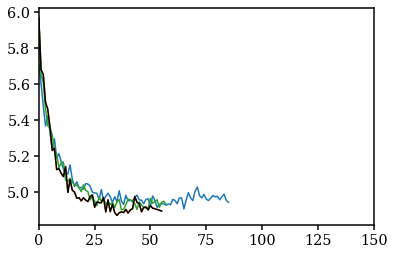

saving to /scratch/network/chhahn/sedflow/spectra/anpe.279x8.p0k.pt


In [9]:
anpes, phats = [], []
valid_logprobs, best_valid_logprobs = [], []
archs = []
for i in range(3): 
    nhidden = int(np.ceil(np.exp(np.random.uniform(np.log(64), np.log(512)))))
    nblocks = int(np.random.uniform(3, 10))
    print('MAF with nhidden=%i; nblocks=%i' % (nhidden, nblocks))
    archs.append('%ix%i' % (nhidden, nblocks))
    anpe = Inference.SNPE(prior=prior, 
                          density_estimator=Ut.posterior_nn('maf', hidden_features=nhidden, num_transforms=nblocks), 
                          device='cuda')

    anpe.append_simulations(
        torch.as_tensor(y_train.astype(np.float32)), 
        torch.as_tensor(x_train.astype(np.float32)))

    phat = anpe.train()

    anpes.append(anpe)
    phats.append(phat)

    valid_logprobs.append(anpe._summary['validation_log_probs'])
    best_valid_logprobs.append(anpe._summary['best_validation_log_probs'])

ibest = np.argmax(best_valid_logprobs)
best_anpe = anpes[ibest]
best_phat = phats[ibest]
best_arch = archs[ibest]

for vl in valid_logprobs:
    plt.plot(-np.array(vl))
plt.plot(-np.array(valid_logprobs[ibest]), c='k')
plt.xlim(0, 150)
plt.show()

#save trained ANPE
fanpe = os.path.join(dat_dir, f'sdss_ivar.noise_nde.{best_arch}.pt')
print('saving to %s' % fanpe)
torch.save(best_phat.state_dict(), fanpe)

In [15]:
best_arch = '279x8'
nhidden, nblocks = 279, 8
fanpe = os.path.join(dat_dir, f'sdss_ivar.noise_nde.{best_arch}.pt')

anpe = Inference.SNPE(prior=prior, 
                      density_estimator=Ut.posterior_nn('maf', hidden_features=nhidden, num_transforms=nblocks), 
                      device='cpu')
# load ANPE
anpe.append_simulations(
    torch.as_tensor(y_train.astype(np.float32)), 
    torch.as_tensor(x_train.astype(np.float32)))

phat = anpe._build_neural_net(torch.as_tensor(y_train.astype(np.float32)), torch.as_tensor(x_train.astype(np.float32)))
phat.load_state_dict(torch.load(fanpe))

anpe._x_shape = Ut.x_shape_from_simulation(torch.as_tensor(y_train.astype(np.float32)))

best_phat = anpe.build_posterior(phat)

# 3. validate $q_\phi({\bf h}, A_{\rm ivar}\,|\,A_{\rm spec}, z)$

In [16]:
y_test = np.concatenate([h_ivar, A_ivar], axis=1)[N_train:]
x_test = np.concatenate([np.log10(A_spec.clip(1e-2, None)), zred], axis=1)[N_train:]

In [17]:
# sample posterior p(theta | x_test_i)
y_recon = []
for _x_test in x_test: 
    _y = best_phat.sample((1,), x=torch.as_tensor(_x_test.astype(np.float32)).to('cpu'), show_progress_bars=False)
    y_recon.append(np.array(_y.detach().to('cpu')[0]))
y_recon = np.array(y_recon)

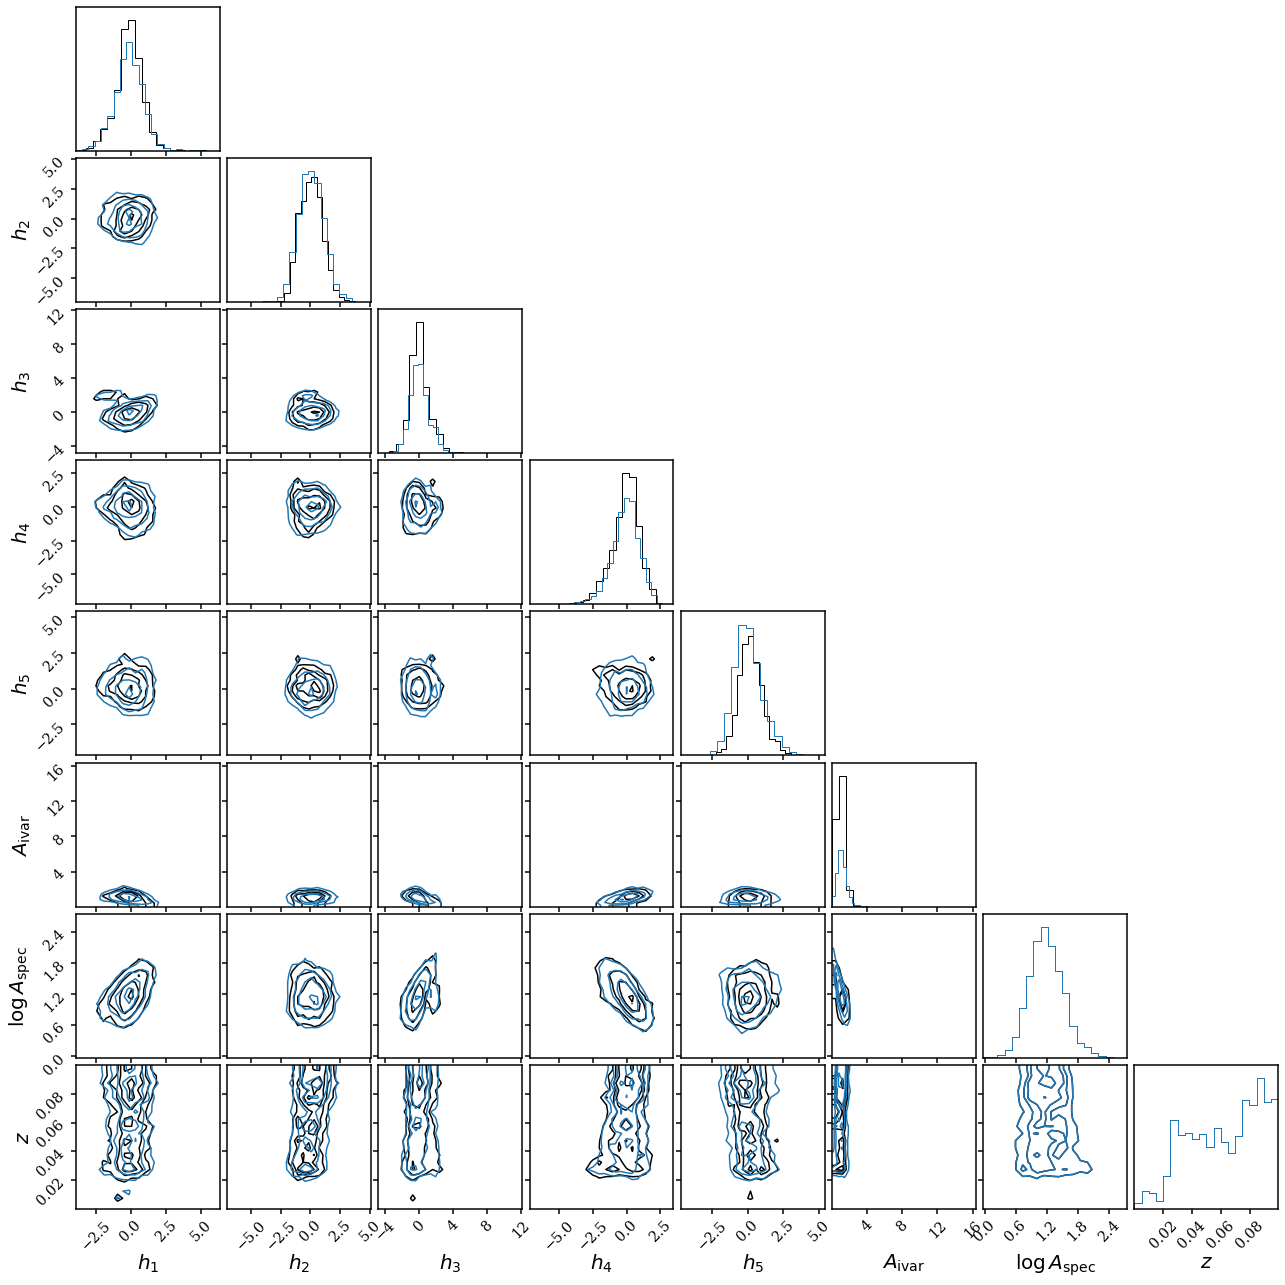

In [25]:
fig = DFM.corner(np.concatenate([y_test, x_test], axis=1),
                 plot_datapoints=False, plot_density=False, color='k')

_ = DFM.corner(np.concatenate([y_recon, x_test], axis=1),                 
               plot_datapoints=False, plot_density=False,
               labels=[r'$h_1$', r'$h_2$', r'$h_3$', r'$h_4$', r'$h_5$', r'$A_{\rm ivar}$', r'$\log A_{\rm spec}$', r'$z$'], 
               label_kwargs={"fontsize": 20}, color='C0', fig=fig)